# ASVspoof5 TCAV Delta Analysis

This notebook loads all per-system TCAV outputs, pairs `spoof` and `bonafide` runs for each system, computes per-concept deltas, and builds a system-level comparison view.

## Setup

Load analysis libraries and set display defaults.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

## Config

Set the output folder, target systems, and analysis save directory.

In [2]:
OUTPUT_DIR = Path('/home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output')
SYSTEM_IDS = [f'A{i:02d}' for i in range(1, 17)]
ANALYSIS_DIR = OUTPUT_DIR / 'analysis'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print('OUTPUT_DIR =', OUTPUT_DIR)
print('exists =', OUTPUT_DIR.exists())

OUTPUT_DIR = /home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output
exists = True


## Helpers

Define partition mapping and pair-loading utilities.

In [3]:
def partition_for_system(system_id: str) -> str:
    numeric = int(system_id[1:])
    if 1 <= numeric <= 8:
        return 'train'
    if 9 <= numeric <= 16:
        return 'dev'
    raise ValueError(f'Unsupported system_id: {system_id}')


def csv_path(system_id: str, example_class: str) -> Path:
    return OUTPUT_DIR / f'tcav_{partition_for_system(system_id)}_{system_id}_{example_class}.csv'


def load_pair(system_id: str) -> pd.DataFrame:
    spoof_path = OUTPUT_DIR / f'tcav_{partition_for_system(system_id)}_{system_id}.csv'
    bonafide_path = csv_path(system_id, 'bonafide')
    assert spoof_path.exists(), f'Missing spoof CSV: {spoof_path}'
    assert bonafide_path.exists(), f'Missing bonafide CSV: {bonafide_path}'

    spoof = pd.read_csv(spoof_path).copy()
    bonafide = pd.read_csv(bonafide_path).copy()

    merged = spoof.merge(
        bonafide,
        on=['system_id', 'source_partition', 'split', 'speaker_id', 'concept_name'],
        suffixes=('_spoof', '_bonafide'),
        validate='one_to_one',
    )
    merged['delta_sign_count'] = merged['sign_count_spoof'] - merged['sign_count_bonafide']
    merged['delta_magnitude'] = merged['magnitude_spoof'] - merged['magnitude_bonafide']
    return merged.sort_values('concept_name').reset_index(drop=True)

## Load Pairs

Load spoof and bonafide outputs for every system and inspect one example merge.

In [4]:
merged_by_system = {system_id: load_pair(system_id) for system_id in SYSTEM_IDS}

preview = pd.concat(
    [merged_by_system['A01'].assign(system_preview='A01')],
    ignore_index=True,
)
display(preview[['system_id', 'concept_name', 'sign_count_spoof', 'sign_count_bonafide', 'delta_sign_count', 'magnitude_spoof', 'magnitude_bonafide', 'delta_magnitude']])

,system_id,concept_name,sign_count_spoof,sign_count_bonafide,delta_sign_count,magnitude_spoof,magnitude_bonafide,delta_magnitude
0,A01,long_constant_thick,0.3825,0.2525,0.1300,-0.159138,-0.306173,0.147035
1,A01,long_dropping_flat_thick,0.3925,0.3375,0.0550,-0.143786,-0.201151,0.057365
2,A01,long_dropping_steep_thick,0.4325,0.2900,0.1425,-0.094290,-0.250034,0.155744
3,A01,long_dropping_steep_thin,0.4375,0.3075,0.1300,-0.095676,-0.232569,0.136893
4,A01,long_rising_flat_thick,0.4900,0.3150,0.1750,-0.028261,-0.220949,0.192688
5,A01,long_rising_steep_thick,0.4450,0.3525,0.0925,-0.069456,-0.189623,0.120167
6,A01,long_rising_steep_thin,0.4075,0.2900,0.1175,-0.130716,-0.254040,0.123324
7,A01,short_constant_thick,0.3975,0.2900,0.1075,-0.122513,-0.257685,0.135172
8,A01,short_dropping_steep_thick,0.3575,0.2775,0.0800,-0.207747,-0.318747,0.111000
9,A01,short_dropping_steep_thin,0.3850,0.2625,0.1225,-0.173400,-0.318100,0.144700


## Build Matrices

Convert per-system deltas into system-by-concept matrices.

In [5]:
delta_sign_matrix = pd.DataFrame(
    {
        system_id: merged_by_system[system_id].set_index('concept_name')['delta_sign_count']
        for system_id in SYSTEM_IDS
    }
).T.sort_index()

delta_mag_matrix = pd.DataFrame(
    {
        system_id: merged_by_system[system_id].set_index('concept_name')['delta_magnitude']
        for system_id in SYSTEM_IDS
    }
).T.sort_index()

display(delta_sign_matrix)
display(delta_mag_matrix)

concept_name,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
A01,0.1300,0.0550,0.1425,0.1300,0.1750,0.0925,0.1175,0.1075,0.0800,0.1225,0.1575,0.1225
A02,0.0475,-0.0100,0.0700,0.0200,0.0675,0.0050,0.0400,0.0325,-0.0600,-0.0075,0.0550,0.0600
A03,0.1125,0.0600,0.1750,0.1450,0.1275,0.1150,0.1300,0.1250,0.0525,0.1025,0.1850,0.1375
A04,0.0100,-0.2000,-0.0750,-0.0575,-0.0275,-0.0450,-0.1125,-0.0975,-0.0975,-0.1250,-0.0150,-0.0025
A05,0.1475,-0.0275,0.0825,0.0625,0.0900,0.0650,0.0025,0.0750,0.0250,0.0325,0.1075,0.1075
A06,-0.0400,-0.1175,-0.1250,-0.0500,-0.0275,-0.1025,-0.0925,-0.0950,-0.1325,-0.0925,-0.0325,-0.0850
A07,0.4700,0.3600,0.4425,0.4375,0.4750,0.4025,0.4400,0.3900,0.4075,0.4450,0.4325,0.4100
A08,0.1600,0.1150,0.1150,0.1600,0.1925,0.0850,0.1575,0.1875,0.1500,0.1275,0.1700,0.1400
A09,0.1500,0.0700,0.1175,0.1150,0.1425,0.1025,0.1525,0.1125,0.0900,0.1300,0.1075,0.1475
A10,0.1775,0.0650,0.1375,0.1425,0.1325,0.1175,0.1175,0.1025,0.0825,0.1100,0.1425,0.1450


concept_name,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
A01,0.147035,0.057365,0.155744,0.136893,0.192688,0.120167,0.123324,0.135172,0.111000,0.144700,0.188226,0.125752
A02,0.079190,-0.028106,0.058608,0.030187,0.083844,0.019246,0.030420,0.039612,-0.023168,0.015562,0.053557,0.068396
A03,0.130515,0.041946,0.127770,0.113967,0.124273,0.098201,0.091702,0.107403,0.067479,0.096286,0.148785,0.121864
A04,0.004887,-0.163823,-0.065217,-0.052382,-0.019949,-0.061737,-0.108105,-0.094818,-0.134798,-0.088723,-0.018226,-0.008310
A05,0.088648,-0.044501,0.043155,0.010034,0.050711,0.026494,-0.010448,0.014672,-0.008997,0.001876,0.062471,0.069266
A06,-0.047633,-0.137048,-0.108036,-0.049553,-0.044560,-0.118560,-0.064364,-0.081312,-0.134895,-0.114556,-0.058197,-0.081718
A07,0.338345,0.263419,0.307145,0.320891,0.362940,0.273482,0.325698,0.325341,0.317307,0.309715,0.345252,0.311231
A08,0.267304,0.191738,0.187922,0.256279,0.287211,0.147537,0.268087,0.249758,0.267890,0.194195,0.290210,0.229061
A09,0.141339,0.088417,0.104832,0.154577,0.149988,0.061533,0.154981,0.128774,0.110733,0.100386,0.135250,0.111798
A10,0.127608,0.066331,0.100817,0.140105,0.153129,0.062206,0.131266,0.117167,0.098467,0.094634,0.140177,0.096084


## Heatmaps

Visualize concept deltas across all systems for both metrics.

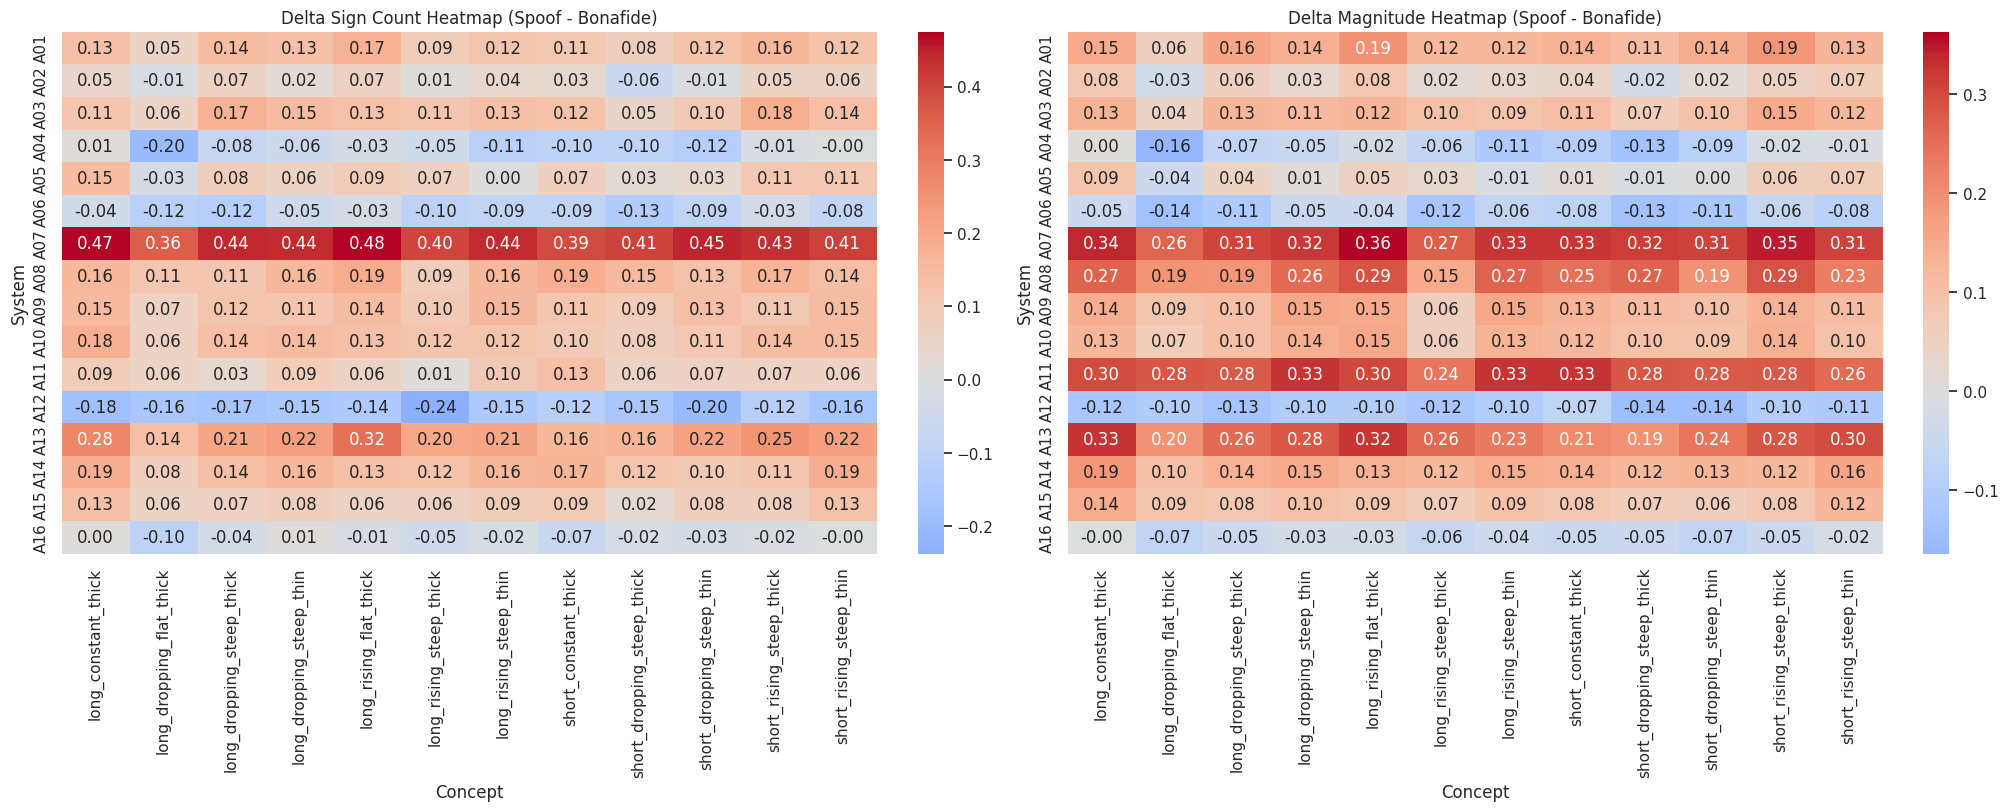

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

sns.heatmap(delta_sign_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Delta Sign Count Heatmap (Spoof - Bonafide)')
axes[0].set_xlabel('Concept')
axes[0].set_ylabel('System')

sns.heatmap(delta_mag_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Delta Magnitude Heatmap (Spoof - Bonafide)')
axes[1].set_xlabel('Concept')
axes[1].set_ylabel('System')

plt.show()

## Distances

Compute pairwise Euclidean distances between system delta vectors.

In [7]:
sign_dist = pd.DataFrame(
    squareform(pdist(delta_sign_matrix.values, metric='euclidean')),
    index=delta_sign_matrix.index,
    columns=delta_sign_matrix.index,
)

mag_dist = pd.DataFrame(
    squareform(pdist(delta_mag_matrix.values, metric='euclidean')),
    index=delta_mag_matrix.index,
    columns=delta_mag_matrix.index,
)

display(sign_dist)
display(mag_dist)

,A01,A02,A03,A04,A05,A06,A07,A08,A09,A10,A11,A12,A13,A14,A15,A16
A01,0.000000,0.331879,0.083516,0.674440,0.226674,0.705186,1.064254,0.141090,0.084632,0.076730,0.228076,0.984626,0.346257,0.142456,0.185051,0.522745
A02,0.331879,0.000000,0.340285,0.374483,0.182825,0.397107,1.388761,0.437850,0.337926,0.344773,0.214680,0.670312,0.668001,0.401030,0.208926,0.236366
A03,0.083516,0.340285,0.000000,0.688045,0.243862,0.721864,1.059953,0.171045,0.122577,0.095786,0.247702,0.996713,0.360061,0.148008,0.196294,0.540555
A04,0.674440,0.374483,0.688045,0.000000,0.472943,0.158015,1.727438,0.777239,0.679692,0.680097,0.534556,0.392930,0.999469,0.735051,0.545917,0.197405
A05,0.226674,0.182825,0.243862,0.472943,0.000000,0.525208,1.261247,0.328976,0.238524,0.222191,0.189835,0.808018,0.541456,0.282378,0.140979,0.348542
A06,0.705186,0.397107,0.721864,0.158015,0.525208,0.000000,1.765188,0.800910,0.709903,0.717243,0.542177,0.309172,1.037349,0.773648,0.573394,0.212191
A07,1.064254,1.388761,1.059953,1.727438,1.261247,1.765188,0.000000,0.975054,1.063444,1.053565,1.246473,2.044162,0.735336,1.009099,1.208168,1.579232
A08,0.141090,0.437850,0.171045,0.777239,0.328976,0.800910,0.975054,0.000000,0.142061,0.150810,0.280669,1.072552,0.286575,0.125648,0.266974,0.621294
A09,0.084632,0.337926,0.122577,0.679692,0.238524,0.709903,1.063444,0.142061,0.000000,0.072629,0.210134,0.987123,0.355642,0.099844,0.157778,0.522135
A10,0.076730,0.344773,0.095786,0.680097,0.222191,0.717243,1.053565,0.150810,0.072629,0.000000,0.233091,0.999031,0.340780,0.098963,0.169724,0.530825


,A01,A02,A03,A04,A05,A06,A07,A08,A09,A10,A11,A12,A13,A14,A15,A16
A01,0.000000,0.358647,0.120672,0.716962,0.397122,0.779005,0.627932,0.373787,0.123170,0.121034,0.550693,0.871141,0.436761,0.117541,0.211072,0.626765
A02,0.358647,0.000000,0.249447,0.367499,0.070101,0.430816,0.977902,0.713066,0.313624,0.277982,0.893765,0.526390,0.775182,0.361445,0.211319,0.280802
A03,0.120672,0.249447,0.000000,0.608455,0.285925,0.671770,0.734574,0.476048,0.114416,0.086622,0.652291,0.763010,0.536759,0.135800,0.113175,0.516972
A04,0.716962,0.367499,0.608455,0.000000,0.328269,0.137480,1.338949,1.070846,0.671791,0.635787,1.256915,0.240913,1.130056,0.721399,0.563775,0.160888
A05,0.397122,0.070101,0.285925,0.328269,0.000000,0.403171,1.015499,0.750869,0.357429,0.321416,0.934084,0.498524,0.810780,0.398706,0.246649,0.249660
A06,0.779005,0.430816,0.671770,0.137480,0.403171,0.000000,1.399249,1.124701,0.719347,0.685761,1.309842,0.132354,1.199148,0.778933,0.617915,0.174547
A07,0.627932,0.977902,0.734574,1.338949,1.015499,1.399249,0.000000,0.291156,0.682970,0.714704,0.128592,1.488710,0.239457,0.629058,0.792452,1.243441
A08,0.373787,0.713066,0.476048,1.070846,0.750869,1.124701,0.291156,0.000000,0.410741,0.443502,0.219931,1.215248,0.195489,0.373277,0.527540,0.971340
A09,0.123170,0.313624,0.114416,0.671791,0.357429,0.719347,0.682970,0.410741,0.000000,0.045432,0.591767,0.809313,0.499611,0.100485,0.138617,0.565448
A10,0.121034,0.277982,0.086622,0.635787,0.321416,0.685761,0.714704,0.443502,0.045432,0.000000,0.626553,0.776914,0.527747,0.126931,0.122898,0.533135


## Neighbors

Find the closest systems for each attack and visualize the nearest-neighbor distances.

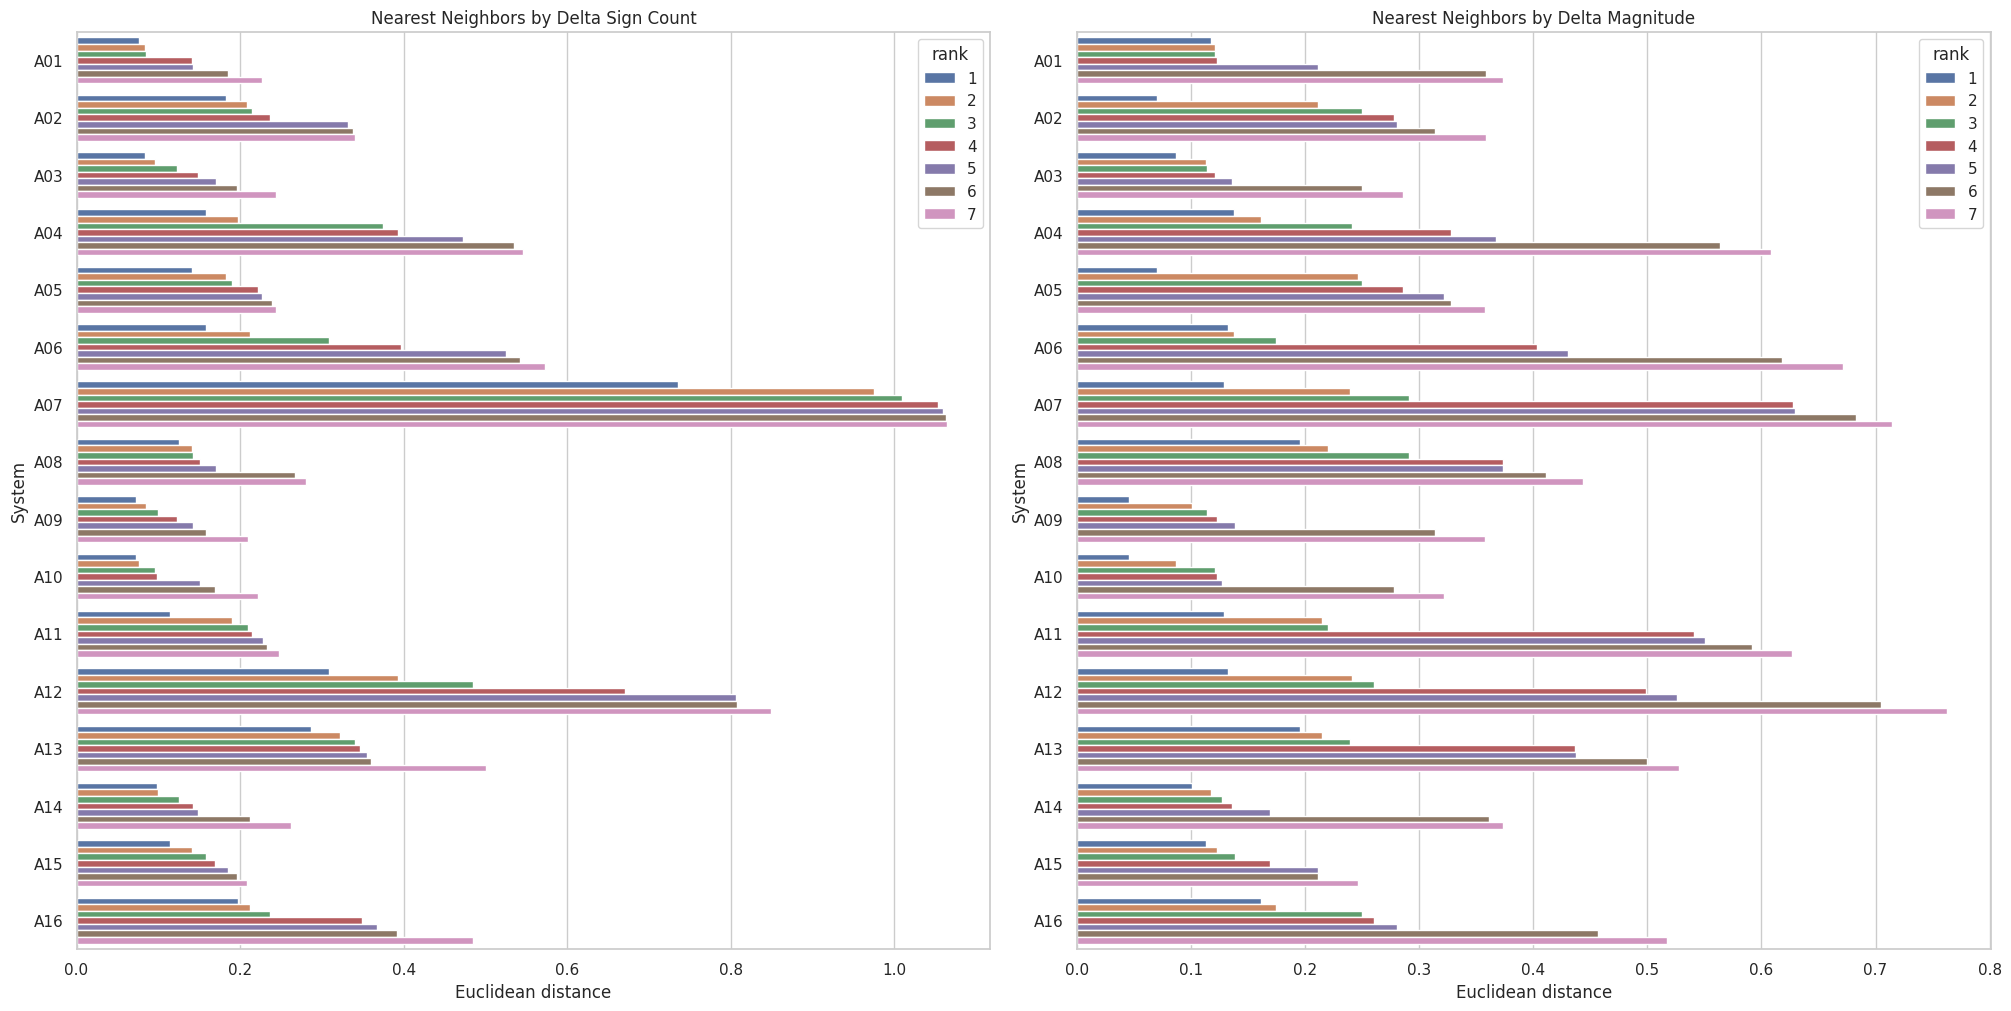

,system_id,rank,neighbor_system,distance
0,A01,1,A10,0.076730
1,A01,2,A03,0.083516
2,A01,3,A09,0.084632
3,A01,4,A08,0.141090
4,A01,5,A14,0.142456
...,...,...,...,...
107,A16,3,A02,0.236366
108,A16,4,A05,0.348542
109,A16,5,A11,0.367381
110,A16,6,A15,0.391847


,system_id,rank,neighbor_system,distance
0,A01,1,A14,0.117541
1,A01,2,A03,0.120672
2,A01,3,A10,0.121034
3,A01,4,A09,0.123170
4,A01,5,A15,0.211072
...,...,...,...,...
107,A16,3,A05,0.249660
108,A16,4,A12,0.260763
109,A16,5,A02,0.280802
110,A16,6,A15,0.456841


In [12]:
def nearest_neighbors(distance_df: pd.DataFrame, top_k: int = 3) -> pd.DataFrame:
    rows = []
    for system_id in distance_df.index:
        ordered = distance_df.loc[system_id].drop(system_id).sort_values()
        for rank, (other_id, dist_value) in enumerate(ordered.head(top_k).items(), start=1):
            rows.append(
                {
                    'system_id': system_id,
                    'rank': rank,
                    'neighbor_system': other_id,
                    'distance': float(dist_value),
                }
            )
    return pd.DataFrame(rows)


neighbors_sign = nearest_neighbors(sign_dist, top_k=7)
neighbors_mag = nearest_neighbors(mag_dist, top_k=7)

fig, axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)

sns.barplot(data=neighbors_sign, x='distance', y='system_id', hue='rank', orient='h', ax=axes[0])
axes[0].set_title('Nearest Neighbors by Delta Sign Count')
axes[0].set_xlabel('Euclidean distance')
axes[0].set_ylabel('System')

sns.barplot(data=neighbors_mag, x='distance', y='system_id', hue='rank', orient='h', ax=axes[1])
axes[1].set_title('Nearest Neighbors by Delta Magnitude')
axes[1].set_xlabel('Euclidean distance')
axes[1].set_ylabel('System')

plt.show()

display(neighbors_sign)
display(neighbors_mag)

## Clustering

Group systems by their delta vectors using hierarchical clustering.

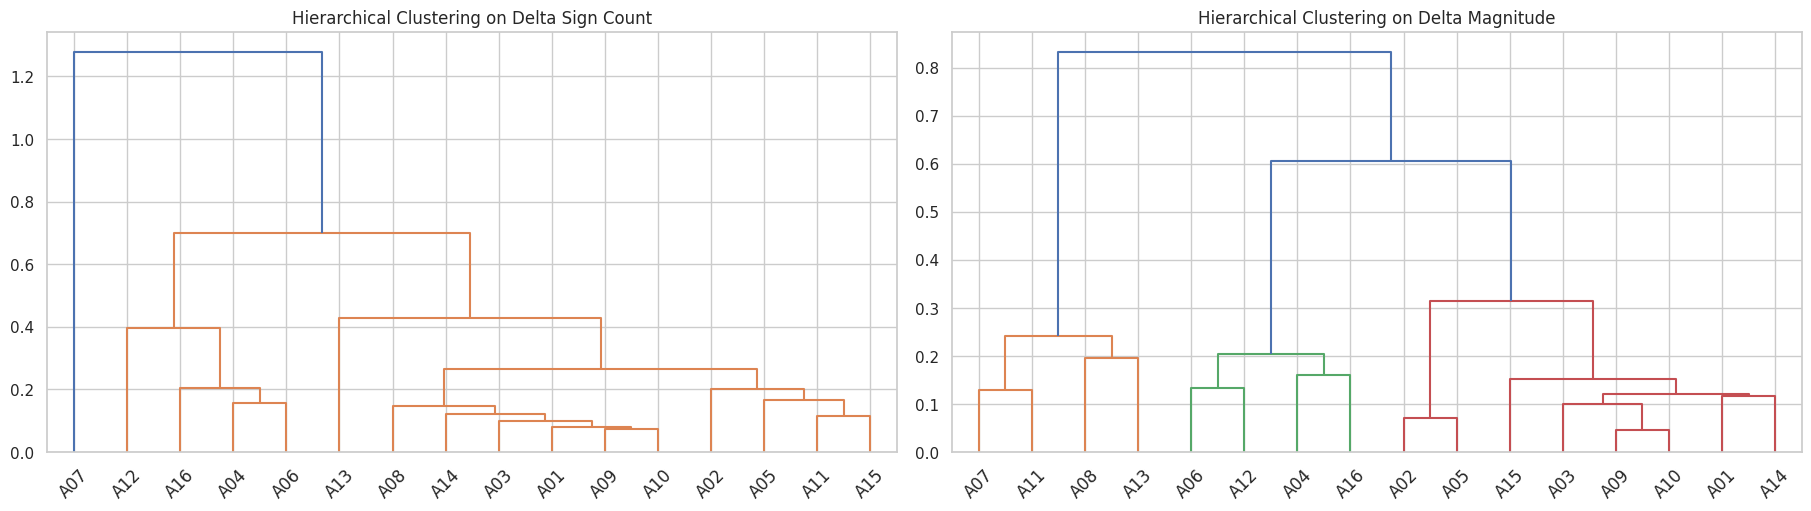

In [9]:
sign_linkage = linkage(pdist(delta_sign_matrix.values, metric='euclidean'), method='average')
mag_linkage = linkage(pdist(delta_mag_matrix.values, metric='euclidean'), method='average')

fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
dendrogram(sign_linkage, labels=delta_sign_matrix.index.tolist(), leaf_rotation=45, ax=axes[0])
axes[0].set_title('Hierarchical Clustering on Delta Sign Count')

dendrogram(mag_linkage, labels=delta_mag_matrix.index.tolist(), leaf_rotation=45, ax=axes[1])
axes[1].set_title('Hierarchical Clustering on Delta Magnitude')
plt.show()

## Ternary View

Create a simplified sign-only summary of the delta sign-count matrix.

concept_name,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
A01,1,0,1,1,1,0,1,1,0,1,1,1
A02,0,0,0,0,0,0,0,0,0,0,0,0
A03,1,0,1,1,1,1,1,1,0,1,1,1
A04,0,-1,0,0,0,0,-1,0,0,-1,0,0
A05,1,0,0,0,0,0,0,0,0,0,1,1
A06,0,-1,-1,0,0,-1,0,0,-1,0,0,0
A07,1,1,1,1,1,1,1,1,1,1,1,1
A08,1,1,1,1,1,0,1,1,1,1,1,1
A09,1,0,1,1,1,1,1,1,0,1,1,1
A10,1,0,1,1,1,1,1,1,0,1,1,1


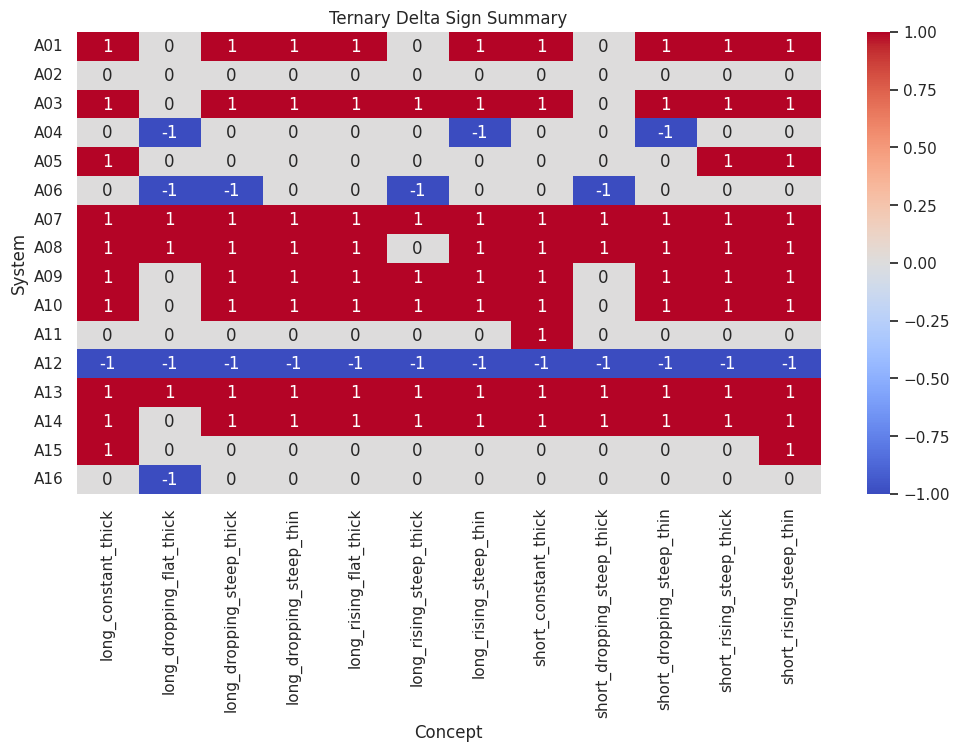

In [10]:
TERNARY_THRESHOLD = 0.10

ternary_sign_matrix = delta_sign_matrix.copy()
ternary_sign_matrix = ternary_sign_matrix.applymap(
    lambda x: 1 if x > TERNARY_THRESHOLD else (-1 if x < -TERNARY_THRESHOLD else 0)
)

display(ternary_sign_matrix)

plt.figure(figsize=(12, 6))
sns.heatmap(ternary_sign_matrix, annot=True, fmt='d', cmap='coolwarm', center=0)
plt.title('Ternary Delta Sign Summary')
plt.xlabel('Concept')
plt.ylabel('System')
plt.show()

## Save Tables

Write the main matrices and neighbor tables to disk for reuse.

In [11]:
# delta_sign_matrix.to_csv(ANALYSIS_DIR / 'analysis_delta_sign_matrix.csv')
# delta_mag_matrix.to_csv(ANALYSIS_DIR / 'analysis_delta_magnitude_matrix.csv')
# sign_dist.to_csv(ANALYSIS_DIR / 'analysis_delta_sign_distance.csv')
# mag_dist.to_csv(ANALYSIS_DIR / 'analysis_delta_magnitude_distance.csv')
# neighbors_sign.to_csv(ANALYSIS_DIR / 'analysis_delta_sign_neighbors.csv', index=False)
# neighbors_mag.to_csv(ANALYSIS_DIR / 'analysis_delta_magnitude_neighbors.csv', index=False)
# ternary_sign_matrix.to_csv(ANALYSIS_DIR / 'analysis_delta_sign_ternary.csv')

# print('Saved analysis tables to', ANALYSIS_DIR)

## Read Results

Use these rules to interpret the tables and plots.

- `delta_sign_count > 0`: the concept pushes more toward spoof than bonafide for that detector.
- `delta_sign_count < 0`: the concept is more bonafide-favoring than spoof-favoring for that detector.
- systems with small pairwise distance in the delta matrices have similar TCAV contrast signatures.
- the ternary matrix is only a simplified secondary view; the raw delta matrices remain the primary representation.